In [1]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

def get_dataframe_from_records(records, add_custom_columns=None):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    if add_custom_columns:
        df = add_custom_columns(df)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])
    # chech that for each group there are 5 entries

    agg_df_check = df.groupby("group").count()
    if (agg_df_check < 5).any().any():
        print("Warning: Some groups have fewer than 5 entries.")

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"
        
        #set min value to row[std_col] to 0.001

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def only_best(run):
    return run.group is not None and run.group.startswith("best_")

def get_records(project, metrics=[], history=[], config=[], get_memory=False, pattern=only_best, verbose=False, regex=None):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    if not regex:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished"}) #, "group":{"$regex": "^best_"}})
    else:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished", "group": {"$regex": regex}})

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not pattern(run):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        if verbose:
            print(f"Processing run {run.id} in group '{group}'")
            # print metrics of the run
            print("Metrics:", [key for key in run.summary.keys() if key.startswith("test_")])

        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        for metric, mode in history:
            if metric not in run.history(keys=[metric]).columns:
                print(f"Warning: Metric '{metric}' not found in history of run {run.id}.")
                continue
            if mode == 'max':
                record[metric] = run.history(keys=[metric])[metric].dropna().max()
            elif mode == 'min':
                record[metric] = run.history(keys=[metric])[metric].dropna().min()
            else:
                record[metric] = run.history(keys=[metric])[metric].dropna().values[-1]

        for c in config:
            if c not in run.config:
                print(f"Warning: Config '{c}' not found in run {run.id}.")
                continue
            record[c] = run.config[c]

        if get_memory:
            # get the tag
            # print("Getting memory info for run:", run.id)
            tag = run.tags[0]
            assert tag.startswith('CUDA_VISIBLE_DEVICES_')
            cuda_device = tag.split('_')[-1]
            memory_metric_id = f'system.gpu.{cuda_device}.memoryAllocatedBytes'
            record['memory'] = run.system_metrics[memory_metric_id]
            hist = run.history(stream='system')
            # print("System history columns:", hist.columns)
            record['memory2'] = hist[memory_metric_id].max()

        records.append(record)
    return records

colors_idxs = {
    "best_stmem_ft": "#636EFAC0",
    "best_stmem_lp": "#636EFAC0",
    "best_jepa_ft": "#EF553BC0",
    "best_jepa_lp": "#EF553BC0",
    "best_ecgfm_ft": "#00CC96C0",
    "best_ecgfm_lp": "#00CC96C0",
    "best_trans_ft": "#AB63FAC0",
    "best_trans_lp": "#AB63FAC0",
    "best_xlstm_ft": "#FFA15AC0",
    "best_xlstm_lp": "#FFA15AC0",
    "best_xlstm_sup": "#19D3F3C0"
}

# base plots

In [2]:
records_sleep_apnea = get_records("train-sleep-apnea_bis", metrics=["test_acc", "test_f1", "test_auc", '_runtime'], config=['batch_size'], get_memory=True, regex="^best_")
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)

100%|██████████| 175/175 [02:26<00:00,  1.20it/s]


In [3]:
# plot with runtimes
dataframe = pd.DataFrame(records_sleep_apnea).set_index("group")
# print(dataframe[dataframe.index == 'best_trans_ft_9m'])
dataframe['memory_adjusted'] = dataframe['memory2'] / dataframe['batch_size']
dataframe['runtime_adjusted'] = dataframe['_runtime'] / dataframe['batch_size']
dataframe = dataframe[['test_auc', '_runtime', 'memory_adjusted', 'runtime_adjusted']].groupby(level=0).agg(['mean', 'std'])
dataframe['_runtime'] = dataframe['_runtime'] / 3600  # convert to hours
dataframe['runtime_adjusted'] = dataframe['runtime_adjusted'] / 3600  # convert to hours
dataframe['memory_adjusted'] = dataframe['memory_adjusted'] / (1024 * 1024 * 1024)  # convert to GB
dataframe

test_auc             _runtime           memory_adjusted  \
                       mean       std       mean       std            mean   
group                                                                        
best_ecgfm_ft_10s  0.691522  0.042679   0.749307  0.006829        0.056465   
best_ecgfm_ft_1m   0.755818  0.028330   0.862217  0.005548        0.166456   
best_ecgfm_ft_20s  0.732915  0.047445   0.750460  0.007801        0.056465   
best_ecgfm_ft_30s  0.722750  0.040323   0.863424  0.008362        0.083577   
best_ecgfm_ft_3m   0.741468  0.032091   2.442820  0.013378        0.482151   
best_ecgfm_ft_5m   0.770809  0.056052   3.956516  0.008551        0.814083   
best_ecgfm_ft_9m   0.778393  0.072225   6.986606  0.055395        1.486443   
best_ecgfm_lp      0.776873  0.071249   1.908449  0.062734        0.180800   
best_jepa_ft_10s   0.675331  0.012957   3.532854  0.024096        0.345946   
best_jepa_ft_1m    0.690438  0.027731  13.199495  0.099019        8.388348   
best_jepa_ft_20s   0.670907  0.016559   5.461037  0.020665        1.101864   
best_jepa_ft_30s   0.652686  0.025504   7.564324  0.031646        2.259758   
best_jepa_lp       0.666892  0.051432   5.554960  0.048852        1.116988   
best_stmem_ft_10s  0.700258  0.030121   2.633463  0.016485        0.325886   
best_stmem_ft_1m   0.684874  0.032594   8.005235  0.034683        6.840790   
best_stmem_ft_20s  0.687620  0.035707   3.227487  0.746068        0.982235   
best_stmem_ft_30s  0.682557  0.019784   4.843649  0.015482        1.926262   
best_stmem_lp      0.598744  0.031628   1.104840  0.004465        0.037330   
best_trans_ft_10s  0.658399  0.031726   0.186790  0.008206        0.017361   
best_trans_ft_1m   0.629798  0.032487   0.230259  0.007112        0.142387   
best_trans_ft_20s  0.619472  0.024882   0.193368  0.008290        0.037864   
best_trans_ft_30s  0.598029  0.062210   0.198968  0.011423        0.059986   
best_trans_ft_3m   0.614597  0.036484   1.032932  0.002321        0.776424   
best_trans_ft_5m   0.636770  0.041220   2.363284  0.011192        1.925652   
best_trans_ft_9m   0.680796  0.044048   6.401156  0.008044        5.356186   
best_trans_lp      0.644381  0.042393   0.114470  0.002982        0.027256   
best_xlstm_ft_10s  0.712283  0.048554   0.276146  0.006157        0.022488   
best_xlstm_ft_1m   0.914163  0.019947   0.296956  0.002107        0.136059   
best_xlstm_ft_20s  0.745335  0.027762   0.281945  0.001063        0.045063   
best_xlstm_ft_30s  0.777324  0.029646   0.289069  0.001879        0.065918   
best_xlstm_ft_3m   0.915131  0.015152   1.068406  0.004634        0.462596   
best_xlstm_ft_5m   0.927839  0.008091   2.154556  0.010523        0.937313   
best_xlstm_ft_9m   0.898796  0.022994   5.267718  0.019446        2.103386   
best_xlstm_lp      0.879130  0.021273   1.016923  0.004160        0.299935   
best_xlstm_sup     0.834288  0.019905   2.644200  0.008153        1.131869   

                            runtime_adjusted            
                        std             mean       std  
group                                                   
best_ecgfm_ft_10s  0.000000         0.001463  0.000013  
best_ecgfm_ft_1m   0.000003         0.003368  0.000022  
best_ecgfm_ft_20s  0.000000         0.001466  0.000015  
best_ecgfm_ft_30s  0.000002         0.001686  0.000016  
best_ecgfm_ft_3m   0.000014         0.038169  0.000209  
best_ecgfm_ft_5m   0.000000         0.123641  0.000267  
best_ecgfm_ft_9m   0.000000         0.436663  0.003462  
best_ecgfm_lp      0.000000         0.014910  0.000490  
best_jepa_ft_10s   0.000000         0.036801  0.000251  
best_jepa_ft_1m    0.153566         3.299874  0.024755  
best_jepa_ft_20s   0.000000         0.170657  0.000646  
best_jepa_ft_30s   0.000000         0.472770  0.001978  
best_jepa_lp       0.005611         0.173592  0.001527  
best_stmem_ft_10s  0.000000         0.027432  0.000172  
best_stmem_ft_1m   0.000000         2.001309  0.008671  
best_stmem_ft_20s  0.000000 

In [4]:
xlstms = ['best_xlstm_ft_10s', 'best_xlstm_ft_20s', 'best_xlstm_ft_30s', 'best_xlstm_ft_1m', 'best_xlstm_ft_3m', 'best_xlstm_ft_5m', 'best_xlstm_ft_9m']
xlstm_progression_runtime = dataframe.loc[xlstms]['_runtime']
xlstm_progression_auc = dataframe.loc[xlstms]['test_auc']
xlstm_memory = dataframe.loc[xlstms]['memory_adjusted']
xlstm_progression_runtime_normalized = dataframe.loc[xlstms]['runtime_adjusted']    

trans = ['best_trans_ft_10s', 'best_trans_ft_20s', 'best_trans_ft_30s', 'best_trans_ft_1m', 'best_trans_ft_3m', 'best_trans_ft_5m', 'best_trans_ft_9m']
trans_progression_runtime = dataframe.loc[trans]['_runtime']
trans_progression_auc = dataframe.loc[trans]['test_auc']
trans_memory = dataframe.loc[trans]['memory_adjusted']
trans_progression_runtime_normalized = dataframe.loc[trans]['runtime_adjusted']

jepa = ['best_jepa_ft_10s', 'best_jepa_ft_20s', 'best_jepa_ft_30s', 'best_jepa_ft_1m']
jepa_progression_runtime = dataframe.loc[jepa]['_runtime']
jepa_progression_auc = dataframe.loc[jepa]['test_auc']
jepa_memory = dataframe.loc[jepa]['memory_adjusted']
jepa_progression_runtime_normalized = dataframe.loc[jepa]['runtime_adjusted']

ecgfm = ['best_ecgfm_ft_10s', 'best_ecgfm_ft_20s', 'best_ecgfm_ft_30s', 'best_ecgfm_ft_1m', 'best_ecgfm_ft_3m', 'best_ecgfm_ft_5m', 'best_ecgfm_ft_9m']
ecgfm_progression_runtime = dataframe.loc[ecgfm]['_runtime']
ecgfm_progression_auc = dataframe.loc[ecgfm]['test_auc']
ecgfm_memory = dataframe.loc[ecgfm]['memory_adjusted']
ecgfm_progression_runtime_normalized = dataframe.loc[ecgfm]['runtime_adjusted']

stmem = ['best_stmem_ft_10s', 'best_stmem_ft_20s', 'best_stmem_ft_30s', 'best_stmem_ft_1m']
stmem_progression_runtime = dataframe.loc[stmem]['_runtime']
stmem_progression_auc = dataframe.loc[stmem]['test_auc']
stmem_memory = dataframe.loc[stmem]['memory_adjusted']
stmem_progression_runtime_normalized = dataframe.loc[stmem]['runtime_adjusted']

x_xlstm = [10, 20, 30, 60, 180, 300, 540]
x_jepa = [10, 20, 30, 60]
x_trans = [10, 20, 30, 60, 180, 300, 540]
x_ecgfm = [10, 20, 30, 60, 180, 300, 540]
x_stmem = [10, 20, 30, 60]

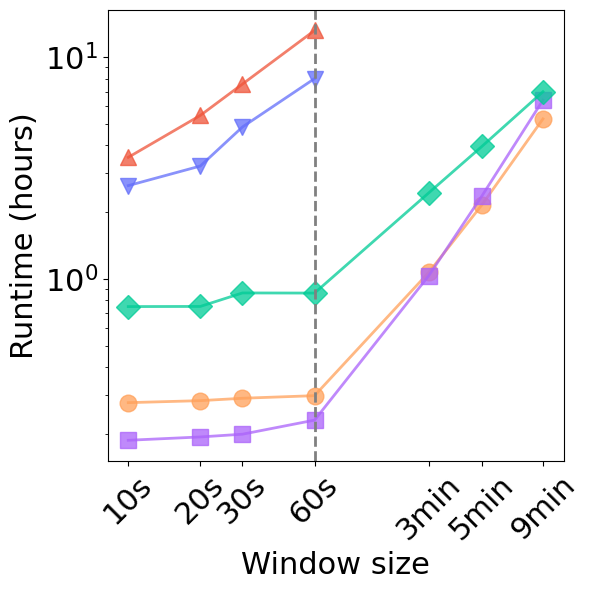

In [60]:
plt.figure(figsize=(6, 6))

# Left y-axis (runtime)
plt.plot(x_xlstm, xlstm_progression_runtime['mean'], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.plot(x_jepa, jepa_progression_runtime['mean'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'], linewidth=2)
plt.plot(x_trans, trans_progression_runtime['mean'], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'], linewidth=2)
plt.plot(x_ecgfm, ecgfm_progression_runtime['mean'], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.plot(x_stmem, stmem_progression_runtime['mean'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'], linewidth=2)

plt.xlabel("Window size", fontdict={'size': 22})
plt.ylabel("Runtime (hours)", fontdict={'size': 22})
plt.tick_params(axis='y')

#set font yticks
plt.tick_params(axis='y', labelsize=22)
plt.loglog()

# add a vertical dotted line at 60
plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'],
    rotation=45,
    fontsize=22
)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)

plt.tight_layout()
plt.savefig("figs/sleep_apnea_runtime.svg", dpi=300)

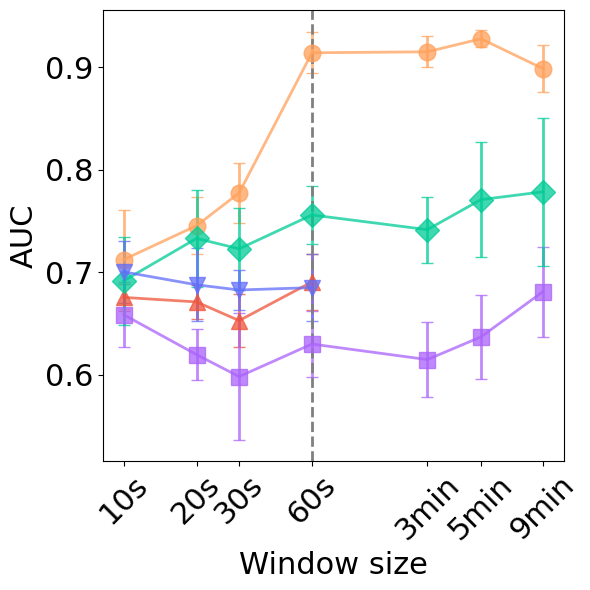

In [61]:
plt.figure(figsize=(6, 6))

# Right y-axis (AUC for xLSTM)
# ax2 = ax1.twinx()
plt.errorbar(x_xlstm, xlstm_progression_auc['mean'], yerr=xlstm_progression_auc['std'], marker='o', markersize=12, label='xECG', capsize=4, color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.errorbar(x_jepa, jepa_progression_auc['mean'], yerr=jepa_progression_auc['std'], marker='^', markersize=12, label='ECG-JEPA', capsize=4, color=colors_idxs['best_jepa_ft'], linewidth=2)
plt.errorbar(x_trans, trans_progression_auc['mean'], yerr=trans_progression_auc['std'], marker='s', markersize=12, label='SimDINOv2\nTransf.', capsize=4, color=colors_idxs['best_trans_ft'], linewidth=2)
plt.errorbar(x_ecgfm, ecgfm_progression_auc['mean'], yerr=ecgfm_progression_auc['std'], marker='D', markersize=12, label='ECGFounder', capsize=4, color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.errorbar(x_stmem, stmem_progression_auc['mean'], yerr=stmem_progression_auc['std'], marker='v', markersize=12, label='ST-MEM', capsize=4, color=colors_idxs['best_stmem_ft'], linewidth=2)

plt.ylabel("AUC", fontdict={'size': 22})
plt.tick_params(axis='y')
plt.xlabel("Window size", fontdict={'size': 22})

plt.xscale("log")
plt.tick_params(axis='y', labelsize=22)
plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'],
    rotation=45,
    fontsize=22
)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)


plt.tight_layout()
plt.savefig("figs/sleep_apnea_auc.svg", dpi=300)


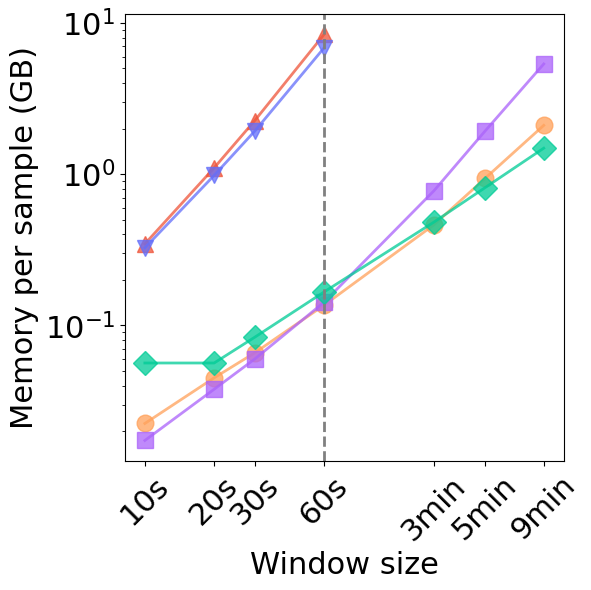

In [13]:
plt.figure(figsize=(6, 6))

# Left y-axis (runtime)
plt.plot(x_xlstm, xlstm_memory['mean'], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.plot(x_jepa, jepa_memory['mean'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'], linewidth=2)
plt.plot(x_trans, trans_memory['mean'], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'], linewidth=2)
plt.plot(x_ecgfm, ecgfm_memory['mean'], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.plot(x_stmem, stmem_memory['mean'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'], linewidth=2)

plt.xlabel("Window size", fontdict={'size': 22})
plt.ylabel("Memory per sample (GB)", fontdict={'size': 22})
plt.tick_params(axis='y')

#set font yticks
plt.loglog()
# plt.xscale("log")

# add a vertical dotted line at 60
plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'],
    rotation=45,
    fontsize=22
)
plt.yticks(fontsize=22)
# plt.yticks([0.005, 0.2, 2, 8], ['0.005', '0.2', '2', '8'], fontsize=18)

plt.tick_params(axis='x', which='minor', bottom=False, top=False, labelsize=22)
# plt.tick_params(axis='y', which='minor', bottom=False, top=False)
# plt.legend(bbox_to_anchor=(1.05, 0.8), loc='upper left', fontsize=22, frameon=False)

plt.tight_layout()
# plt.legend(fontsize=15, loc='lower right', frameon=False)

# set legend outside of the plot
plt.savefig("figs/sleep_apnea_memory.svg", dpi=300)


# computation inference

In [ ]:
import utils.utils as utils
import dataset.sleep_apnea as sleep_apnea
from dataset.generic_utils import get_transforms
from torch.utils.data import DataLoader
import torch
import pandas as pd
import time

from fvcore.nn import FlopCountAnalysis 

windows = [(10, 0), (20, 0), (30, 0), (60, 0), (60, 120), (60, 240), (60, 480), (60, 1440)]  # in seconds

batch_size = 1
num_workers = 1

@torch.no_grad()
def measure_inference_time(config, samples=1):
    tortn = pd.DataFrame(columns=['len', 'avg_inference_time'])
    for window_size, context_size in windows:
        try:
            config.window_size = window_size
            config.context_size = context_size

            config.max_length_signal = (config.window_size + config.context_size) * config.sampling_freq
            print(f"\n\nMeasuring inference time for window size {config.window_size}s and context size {config.context_size}s (total {config.max_length_signal} samples)")
            feature_classification = config.window_size % 60 == 0
            base_model = utils.get_base_model(config, feature_classification=feature_classification, sleep_apnea=True, compile_model=False)
            base_model = utils.change_positional_embedding_if_needed(base_model, config)

            # print(base_model)

            base_model.eval()
            base_model.to('cuda')

            dataset =  sleep_apnea.ECGSleepApneaDataset(config, split='train', augmentations=get_transforms(config))
            dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, collate_fn=sleep_apnea.make_collate_fn(config, split='train'), drop_last=True)

            # Measure inference time
            total_time = 0.0
            total_samples = 0
            total_flops = 0
            for i, batch in enumerate(dataloader):
                if total_samples >= samples:
                    break
                x = batch["signals"].to('cuda')
                targets = batch['labels'].to('cuda')

                if i == 0:
                    print('signal shape:', x.shape)

                torch.cuda.synchronize()  # ensure GPU finished
                # Measure time    
                # with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                start_time = time.time()
                _ = base_model(x)
                torch.cuda.synchronize()  # ensure GPU finished
                # preds = (torch.sigmoid(logits) > 0.5).float()
                # loss_cls = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='mean')
                # loss_cls.backward()
                end_time = time.time()

                total_time += (end_time - start_time)
                total_samples += config.batch_size  

                flops = FlopCountAnalysis(base_model, x)
                flops.tracer_warnings('none')
                total_flops += flops.total()

            avg_time = total_time / total_samples if total_samples > 0 else 0
            avg_flops = total_flops / total_samples  if total_samples > 0 else 0

            print(f"Window: {window_size}s, Context: {context_size}s, Avg Inference Time: {avg_time:.6f}s, FLOPs: {np.log(avg_flops)}")

            # add row to dataframe
            tortn = pd.concat([tortn, pd.DataFrame({'len': [window_size + context_size], 'avg_inference_time': [avg_time], 'avg_flops': [avg_flops]})], ignore_index=True)
        except Exception as e:
            tortn = pd.concat([tortn, pd.DataFrame({'len': [window_size + context_size], 'avg_inference_time': [np.nan], 'avg_flops':[np.nan]})], ignore_index=True)
            print(e)
    return tortn
        

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
config_orig = utils.parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = False
config_orig.use_st_mem = True
config_orig.sampling_freq = 250
config_orig.patch_size = 75

stmem_times = measure_inference_time(config_orig)

In [ ]:
config_orig = utils.parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = False
config_orig.use_st_mem = False

config_orig.sampling_freq = 100
config_orig.patch_size = 25
config_orig.xlstm_config = ["s","s","m","m","s","s","m","m","s"]
config_orig.checkpoint = 'pretrained_models/simdino/no_mimic_xlstm.ckpt'

config_orig.embedding_size = 1024
config_orig.encoder_type = 'vanilla'
config_orig.cls_type = 'max'

xecg_times = measure_inference_time(config_orig)

In [6]:
config_orig = utils.parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = True
config_orig.use_ecg_jepa = False
config_orig.use_stmem = False

config_orig.sampling_freq = 500

ecg_fm_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 5000 samples)
Changing positional embedding to new sequence length 0
Training records: ['a04', 'c05', 'a18', 'a11', 'a09', 'c04', 'c09', 'c10', 'a13', 'c07', 'c06', 'a20', 'a12', 'b03', 'a06', 'b02', 'a01', 'a08', 'a15', 'c03', 'c01', 'b05', 'c08', 'a16', 'a03', 'a05', 'a10', 'b01']


Loading samples: 100%|██████████| 28/28 [00:00<00:00, 58.46it/s]

Total samples: 81406, total annotations: 81406, total segment ids: 81406


signal shape: torch.Size([1, 5000, 12])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20])
torch.Size([1, 1024, 20]

/tmp/ipykernel_3063394/702094708.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tortn = pd.concat([tortn, pd.DataFrame({'len': [window_size + context_size], 'avg_inference_time': [avg_time]})], ignore_index=True)


...

Total samples: 13561, total annotations: 13561, total segment ids: 13561


signal shape: torch.Size([1, 270000, 12])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.Size([1, 1024, 1055])
torch.

Loading samples: 100%|██████████| 28/28 [00:00<00:00, 95.68it/s] 

Total samples: 13561, total annotations: 13561, total segment ids: 13561


signal shape: torch.Size([1, 510000, 12])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.Size([1, 1024, 1993])
torch.

In [8]:
config_orig = utils.parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = False
config_orig.use_st_mem = False

config_orig.patch_size = 25

config_orig.encoder_type = 'transformer'
config_orig.embedding_size = 768

config_orig.sampling_freq = 100


transformer_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 1000 samples)
using linear patch embedding
Changing positional embedding to new sequence length 0
Original positional embedding shape: torch.Size([1, 50, 768])
No need to change positional embedding, current max sequence length is 49
Training records: ['a04', 'c05', 'a18', 'a11', 'a09', 'c04', 'c09', 'c10', 'a13', 'c07', 'c06', 'a20', 'a12', 'b03', 'a06', 'b02', 'a01', 'a08', 'a15', 'c03', 'c01', 'b05', 'c08', 'a16', 'a03', 'a05', 'a10', 'b01']


Loading samples: 100%|██████████| 28/28 [00:00<00:00, 60.90it/s]

Total samples: 81406, total annotations: 81406, total segment ids: 81406


signal shape: torch.Size([1, 1000, 12])
Window: 10s, Context: 0s, Avg Inference Time: 0.002434s


Measuring inference time for window size 20s and context size 0s (total 2000 samples)
using linear patch embedding
Changing positional embedding to new sequence length 0
Original positional embedding shape: torch.Size([1, 50, 768])
repeated left pe shape: torch.Size([1, 16, 768])
repeated right pe shape: torch.Size([1, 16, 768])


/tmp/ipykernel_3063394/702094708.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tortn = pd.concat([tortn, pd.DataFrame({'len': [window_size + context_size], 'avg_inference_time': [avg_time]})], ignore_index=True)


...

Loading samples: 100%|██████████| 28/28 [00:00<00:00, 103.24it/s]

Total samples: 13561, total annotations: 13561, total segment ids: 13561


signal shape: torch.Size([1, 54000, 12])
Window: 60s, Context: 480s, Avg Inference Time: 0.031410s


Measuring inference time for window size 60s and context size 960s (total 102000 samples)
using linear patch embedding
Changing positional embedding to new sequence length 1920
Original positional embedding shape: torch.Size([1, 50, 768])
repeated left pe shape: torch.Size([1, 2016, 768])
repeated right pe shape: torch.Size([1, 2016, 768])
Training records: ['a04', 'c05', 'a18', 'a11', 'a09', 'c04', 'c09', 'c10', 'a13', 'c07', 'c06', 'a20', 'a12', 'b03', 'a06', 'b02', 'a01', 'a08', 'a15', 'c03', 'c01', 'b05', 'c08', 'a16', 'a03', 'a05', 'a10', 'b01']


Loading samples: 100%|██████████| 28/28 [00:00<00:00, 95.26it/s]


Total samples: 13561, total annotations: 13561, total segment ids: 13561
signal shape: torch.Size([1, 102000, 12])
Window: 60s, Context: 960s, Avg Inference Time: 0.087249s


In [ ]:
config_orig = utils.parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = True
config_orig.use_stmem = False
config_orig.sampling_freq = 250
config_orig.patch_size = 50
config_orig.leads = ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

jepa_times = measure_inference_time(config_orig)

[]

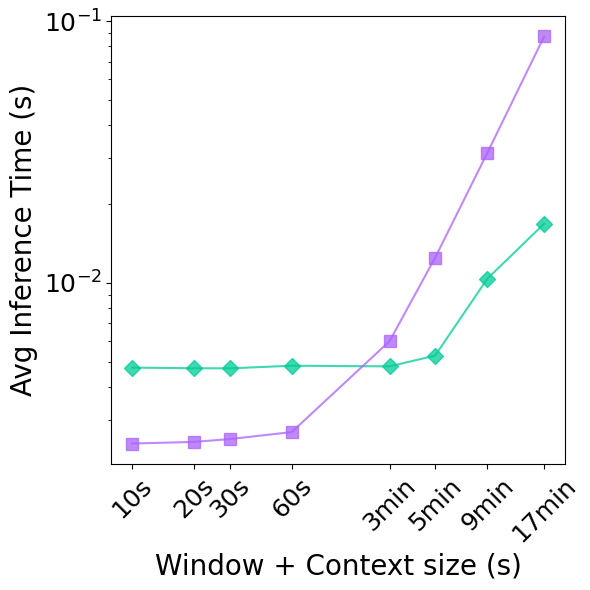

In [ ]:
import matplotlib.pyplot as plt

# plot times
plt.figure(figsize=(6, 6))

plt.plot(xecg_times['len'][:-1], xecg_times['avg_flops'][:-1], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.plot(ecg_fm_times['len'][:-1], ecg_fm_times['avg_flops'][:-1], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'],linewidth=2)
plt.plot(jepa_times['len'], jepa_times['avg_flops'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'],linewidth=2)
plt.plot(stmem_times['len'], stmem_times['avg_flops'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'],linewidth=2)
plt.plot(transformer_times['len'][:-1], transformer_times['avg_flops'][:-1], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'],linewidth=2)  
plt.xlabel("Window size", fontdict={'size': 22})
plt.ylabel("FLOPs", fontdict={'size': 22})
plt.tick_params(axis='y')
#set font yticks
plt.tick_params(axis='y', labelsize=22)
plt.loglog()

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540], #, 1500],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'], #, '27min'],
    rotation=45,
    fontsize=22
)

plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)   
plt.tight_layout()
plt.savefig('/home/q036rl/MIT-BIH_ecg_arrhytmia/figs/sleep_apnea_flops.svg', dpi=300)

[]

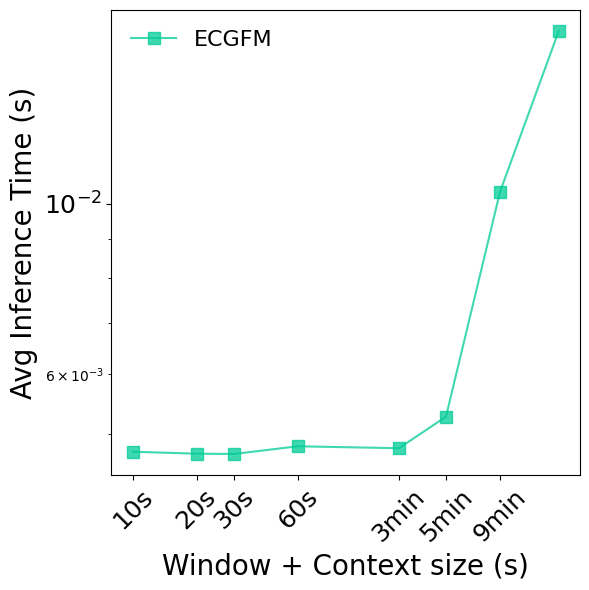

In [ ]:
import matplotlib.pyplot as plt

# plot times
plt.figure(figsize=(6, 6))

plt.plot(xecg_times['len'][:-1], xecg_times['avg_inference_time'][:-1], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'])
plt.plot(ecg_fm_times['len'][:-1], ecg_fm_times['avg_inference_time'][:-1], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'])
plt.plot(jepa_times['len'], jepa_times['avg_inference_time'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'])
plt.plot(stmem_times['len'], stmem_times['avg_inference_time'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'])
plt.plot(transformer_times['len'][:-1], transformer_times['avg_inference_time'][:-1], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'])  
plt.xlabel("Window + Context size (s)", fontdict={'size': 22})
plt.ylabel("Avg Inference Time (s)", fontdict={'size': 22})
plt.tick_params(axis='y')
#set font yticks
plt.tick_params(axis='y', labelsize=22)
plt.loglog()

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540], #,, 1500],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'], # '27min'],
    rotation=45,
    fontsize=22
)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)   
plt.tight_layout()
plt.savefig('/home/q036rl/MIT-BIH_ecg_arrhytmia/figs/sleep_apnea_avg_inference.svg', dpi=300)